In [29]:
# pip install vireoSNP

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import vireoSNP

In [2]:
cwd = os.getcwd()

In [5]:
def match_sample_id():
    
    # match bulk to dissociated bulk
    res = vireoSNP.vcf.match_VCF_samples(
        cwd + "/../data/bcftools/bcftools_bulk_filter_mean.vcf", 
        cwd + "/../data/bcftools/bcftools_diss_bulk_filter_mean.vcf", 
        GT_tag1='PL', 
        GT_tag2='PL',
    )
    
    df = pd.DataFrame(
        {
            "diss bulk sample id": res["matched_donors2"],
            "bulk sample id": res["matched_donors1"],
        }
    )
    # Clean up "sample id" columns
    df = df.replace({r"\d{6}/": ""}, regex=True)
        
    return res, df

In [6]:
res, df = match_sample_id()

Shape for Geno Prob in VCF1: (3549736, 35, 3)
Shape for Geno Prob in VCF2: (1030745, 31, 3)
n_variants in VCF1, VCF2 and matched: 3549736, 1030745, 847638
aligned donors:
['230509/2018' '230509/2023' '230509/2094' '230509/2126' '230509/2129'
 '230509/2186' '230509/2202' '230509/2209' '230509/2240' '230509/2309'
 '230509/2313' '230509/2401' '230509/2407' '230509/2444' '230509/2483'
 '230509/2526' '230626/2216' '230626/2221' '230626/2230' '230626/2238'
 '230626/2246' '230626/2268' '230626/2296' '230626/2364' '230626/2408'
 '230626/2423' '230626/2430' '230626/2455' '230626/2460' '230626/2466'
 '230626/2477']
['230414/2018' '230414/2023' '230418/2094' '230414/2126' '230414/2129'
 '230418/2186' '230414/2202' '230418/2216' '230418/2246' '230414/2313'
 '230414/2364' '230414/2407' '230414/2408' '230418/2455' '230414/2526'
 '230414/2209' '230414/2221' '230418/2230' '230414/2238' '230414/2240'
 '230414/2249' '230414/2278' '230418/2514' '230414/2401' '230414/2416'
 '230418/2309' '230418/2423' '23

In [ ]:
# df = pd.read_csv(cwd + "/../data/bcftools/heatmap_raw_all_v_all.csv", index_col=0)

In [27]:
pair_df = df.copy()
df = pd.DataFrame(
    res["matched_GPb_diff"],
    columns=res["matched_donors2"],
    index=res["matched_donors1"],
)

In [47]:
pair_df = pd.DataFrame(
    {
        "bulk sample id": res["matched_donors1"],
        "diss bulk sample id": res["matched_donors2"],
    }
)

In [49]:
pair_df

,bulk sample id,diss bulk sample id
0,230509/2018,230414/2018
1,230509/2023,230414/2023
2,230509/2094,230418/2094
3,230509/2126,230414/2126
4,230509/2129,230414/2129
5,230509/2186,230418/2186
6,230509/2202,230414/2202
7,230509/2209,230418/2216
8,230509/2240,230418/2246
9,230509/2309,230414/2313


In [28]:
df.index = df.index.str.replace(r"\d{6}/", "", regex=True)

In [29]:
df.columns = df.columns.str.replace(r"\d{6}/", "", regex=True)

In [ ]:
sample_order_df = pd.DataFrame(
    {"samples": df.columns}
)
sample_order_df["sample_id"] = sample_order_df["samples"].str[-4:]
sample_order_df["date"] = sample_order_df["samples"].str[:4]
sample_order_df.loc[sample_order_df["date"]=="2304", "sample_type"] = "diss_bulk"
sample_order_df.loc[sample_order_df["date"]!="2304", "sample_type"] = "bulk"
sample_order_df = sample_order_df.sort_values(by=["sample_type", "sample_id"])

sample_order_df

sample_order_lst = list(sample_order_df["samples"])

sorted_df = df[sample_order_lst]
sorted_df = sorted_df.loc[sample_order_lst]


In [38]:
sorted_df = df[sorted(df.columns)]
sorted_df = sorted_df.loc[sorted(sorted_df.index)]

In [51]:
len(sorted_df.index)

31

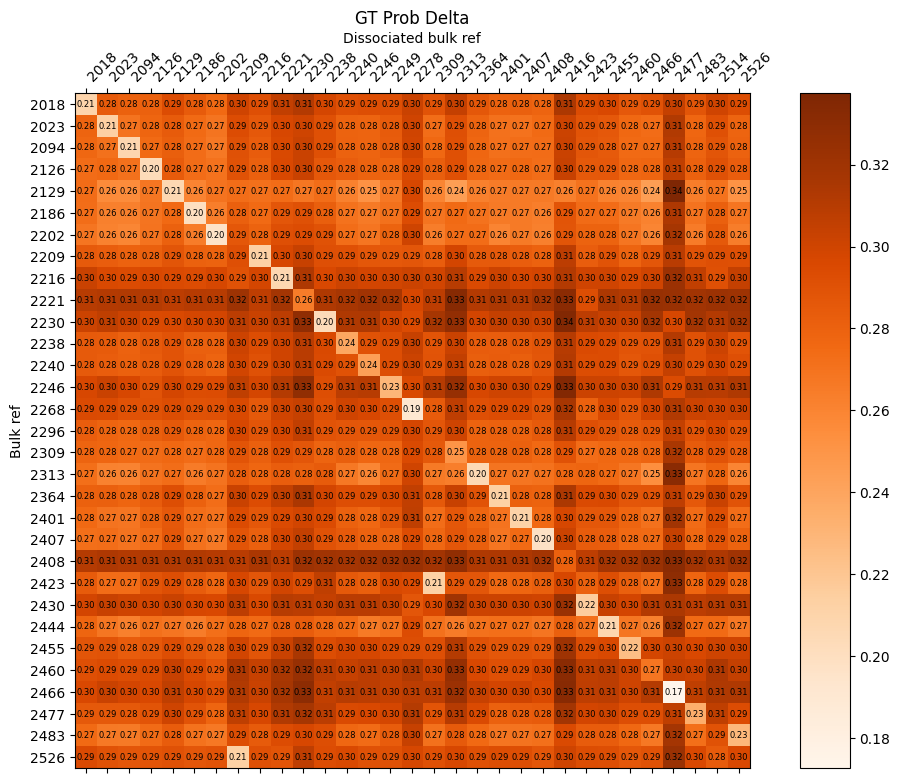

In [54]:
fig, ax = plt.subplots(figsize=(10, 10))
heatmap = ax.matshow(sorted_df, cmap="Oranges")

# Pool lines
# plt.axhline(y=3.5, color='black', linestyle='--')
# plt.axhline(y=6.5, color='black', linestyle='--')
# plt.axhline(y=10.5, color='black', linestyle='--')
# plt.axhline(y=13.5, color='black', linestyle='--')
# plt.axhline(y=16.5, color='black', linestyle='--')
# plt.axhline(y=20.5, color='black', linestyle='--')
# plt.axhline(y=23.5, color='black', linestyle='--')
# plt.axhline(y=27.5, color='black', linestyle='--')
# plt.axhline(y=30.5, color='black', linestyle='--')

# Numbers in grid
for (i, j), z in np.ndenumerate(sorted_df):
    ax.text(j, i, "{:.2f}".format(z), ha="center", va="center", fontdict={"fontsize": 6})

ax.set_xticks(np.arange(len(df)))
ax.set_yticks(np.arange(len(df)))
ax.set_xticklabels(sorted_df.columns, rotation=45, ha="left", fontdict={"fontsize": 10})
ax.set_yticklabels(sorted_df.index, fontdict={"fontsize": 10})
ax.xaxis.set_label_position("top")
ax.set_xlabel("Dissociated bulk ref")
ax.set_ylabel("Bulk ref")
ax.set_title("GT Prob Delta")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size=0.5, pad=0.5)
cbar = fig.colorbar(heatmap, cax=cax)

plt.show()

In [45]:
filename = f"../figures/diss_vs_bulk_ref/GT_delta_prob_filter_mean"
fig.savefig(filename + ".pdf", bbox_inches="tight")
fig.savefig(filename + ".png", bbox_inches="tight")

# Comparing filtering vs no filtering

In [76]:
pair_no_filter = pd.read_csv(cwd + "/../data/sample_pairing_no-filter.csv")
pair_filter1 = pd.read_csv(cwd + "/../data/sample_pairing_filter1.csv")
pair_filter2 = pd.read_csv(cwd + "/../data/sample_pairing_filter2.csv")
pair_filter3 = pd.read_csv(cwd + "/../data/sample_pairing_filter3.csv")

In [153]:
df = pd.merge(pair_no_filter, pair_filter1, on="bulk sample id", suffixes=[" no", " 1"], how="outer")
df = pd.merge(df, pair_filter2, on="bulk sample id", how="outer")
df = pd.merge(df, pair_filter3, on="bulk sample id", suffixes=[" 2", " 3"], how="outer")

In [154]:
df = df.sort_values(by="bulk sample id").reset_index(drop=True)

In [155]:
df["bulk sample id"] = df["bulk sample id"].astype("str")
df["diss bulk sample id no"] = df["diss bulk sample id no"].astype("Int64").astype("str")
df["diss bulk sample id 1"] = df["diss bulk sample id 1"].astype("Int64").astype("str")
df["diss bulk sample id 2"] = df["diss bulk sample id 2"].astype("Int64").astype("str")
df["diss bulk sample id 3"] = df["diss bulk sample id 3"].astype("Int64").astype("str")

In [157]:
cmap=plt.colormaps["gist_rainbow"]

In [160]:
# Get all sample ids, sort, and remove the nan at the end
sample_ids = sorted(set(df["bulk sample id"]) | set(df["diss bulk sample id 1"]) | set(df["diss bulk sample id 2"]) | set(df["diss bulk sample id 3"]) | set(df["diss bulk sample id no"]))[:-1]

In [163]:
color_dict = {
    sample_ids[i]: i for i in range(len(sample_ids))
}

shadow_df = df.copy()
shadow_df.replace(color_dict, inplace=True)

/var/folders/yj/bt5772fx4p1cg9s9jbwzf0r00000gp/T/ipykernel_41197/2684966974.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shadow_df.replace(color_dict, inplace=True)


In [174]:
shadow_df.replace("<NA>", np.nan, inplace=True)

/var/folders/yj/bt5772fx4p1cg9s9jbwzf0r00000gp/T/ipykernel_41197/936780263.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shadow_df.replace("<NA>", np.nan, inplace=True)


In [179]:
shadow_df = shadow_df.astype(float)

In [199]:
reverse_dict = {v: k for k, v in color_dict.items()}

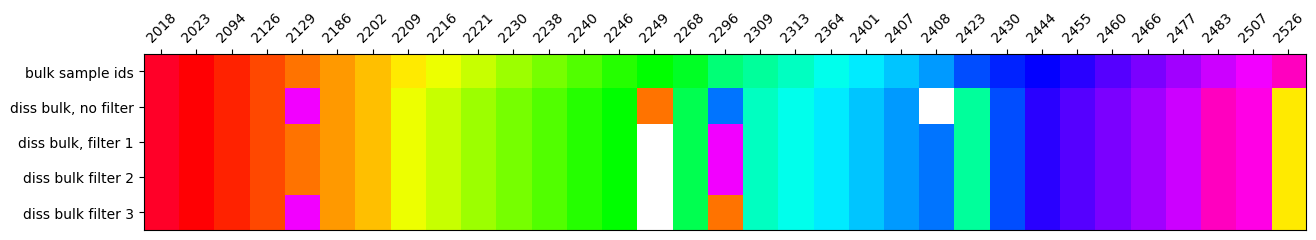

In [207]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))

cmap=plt.colormaps["gist_rainbow"]

plt.imshow(shadow_df.T, cmap="gist_rainbow")
ax.set_xticks(range(len(shadow_df)))
ax.set_xticklabels(
    labels=shadow_df["bulk sample id"].astype(int).replace(reverse_dict),
    rotation=45,
    )
ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)
ax.set_yticks(range(5))
ax.set_yticklabels(["bulk sample ids", "diss bulk, no filter", "diss bulk, filter 1", "diss bulk filter 2", "diss bulk filter 3"])

plt.show()

In [208]:
filename = f"../figures/diss_vs_bulk_ref/label_matching_heatmap"
fig.savefig(filename + ".pdf", bbox_inches="tight")
fig.savefig(filename + ".png", bbox_inches="tight")